# Targeted road closures versus random road closures

This notebook answers:

**How much damage do targeted road closures cause compared with random road closures, and does this depend on the courier assignment strategy?**

The experiment closes the same number of physical road segments in both scenarios, reroutes every order, and compares NAC with SWB at fleet sizes of 200 and 500.


## Imports 


In [1]:
from pathlib import Path
from collections import Counter
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

## Load the data 


In [3]:
# Load the road network
graph_path = Path("../data/clean/dc_drive_clean.graphml")

# Load orders data
orders_path = Path("../data/clean/dc_orders_sim.csv")
orders = pd.read_csv(orders_path)

# Load delivery data
deliveries_path = Path("../data/clean/dc_delivery_events.csv")
deliveries = pd.read_csv(deliveries_path)

orders.head()


,order_id,time_s,hour,pickup_node,dropoff_node,drive_time_s,drive_dist_m
0,1,81.8,0,49743231,646216520,1133.4,14133.0
1,2,110.9,0,774340109,49779846,349.3,3917.0
2,3,149.8,0,49793773,49839482,832.2,9764.0
3,4,209.9,0,49745240,49745636,154.5,1763.0
4,5,304.0,0,4807605970,49800282,346.0,3862.0


## Build the routing graph

The GraphML file may contain multiple directed edges between the same two nodes. The code keeps the fastest edge. A road closure removes both directions of the same physical segment.


In [4]:
def read_graphml_edges(path):
    key_names = {}
    nodes = []
    edges = []

    for event, element in ET.iterparse(path, events=("start", "end")):
        tag = element.tag.rsplit("}", 1)[-1]

        if event == "start" and tag == "key":
            key_names[element.get("id")] = element.get("attr.name")

        elif event == "end" and tag == "node":
            nodes.append(int(element.get("id")))
            element.clear()

        elif event == "end" and tag == "edge":
            values = {
                key_names.get(child.get("key")): child.text
                for child in element
                if child.tag.rsplit("}", 1)[-1] == "data"
            }
            edges.append(
                (
                    int(element.get("source")),
                    int(element.get("target")),
                    float(values["travel_time"]),
                )
            )
            element.clear()

    return nodes, edges


def build_routing_graph(nodes, edges, closed_segments=frozenset()):
    node_to_index = {node: i for i, node in enumerate(nodes)}
    fastest_edge = {}

    for u, v, travel_time in edges:
        segment = (min(u, v), max(u, v))
        if segment in closed_segments:
            continue

        edge = (node_to_index[u], node_to_index[v])
        if edge not in fastest_edge or travel_time < fastest_edge[edge]:
            fastest_edge[edge] = travel_time

    rows = np.array([edge[0] for edge in fastest_edge], dtype=np.int32)
    columns = np.array([edge[1] for edge in fastest_edge], dtype=np.int32)
    weights = np.array(list(fastest_edge.values()), dtype=float)

    graph = csr_matrix(
        (weights, (rows, columns)),
        shape=(len(nodes), len(nodes)),
    )
    return graph, node_to_index


nodes, edges = read_graphml_edges(graph_path)
baseline_graph, node_to_index = build_routing_graph(nodes, edges)

all_segments = sorted({(min(u, v), max(u, v)) for u, v, _ in edges})

print(f"Nodes: {len(nodes):,}")
print(f"Directed edges: {len(edges):,}")
print(f"Physical road segments: {len(all_segments):,}")


Nodes: 10,027
Directed edges: 26,938
Physical road segments: 16,267


## Calculate the baseline routes

There are only 898 unique pickup nodes, so shortest paths are calculated once from each pickup node and then matched back to the 15,188 orders.


In [5]:
source_nodes = np.array(sorted(orders["pickup_node"].unique()))
source_indices = np.array([node_to_index[int(node)] for node in source_nodes])
source_row = {int(node): i for i, node in enumerate(source_nodes)}

order_source_rows = orders["pickup_node"].map(source_row).to_numpy()
dropoff_indices = orders["dropoff_node"].map(node_to_index).to_numpy()

baseline_distances, predecessors = dijkstra(
    baseline_graph,
    directed=True,
    indices=source_indices,
    return_predecessors=True,
)

baseline_order_time = baseline_distances[order_source_rows, dropoff_indices]
baseline_mae_s = np.mean(
    np.abs(baseline_order_time - orders["drive_time_s"].to_numpy())
)

print(f"Mean absolute difference from saved drive times: {baseline_mae_s:.2f} seconds")


Mean absolute difference from saved drive times: 0.66 seconds


The reconstructed routes match the saved order travel times within about one second, so the routing graph is consistent with the order data.


## Define targeted and random closures

This notebook closes **1% of the 16,267 physical road segments**, or **163 segments**.

- **Targeted closures:** close the 163 segments used by the largest number of observed baseline delivery routes.
- **Random closures:** close 163 randomly selected segments. Repeat this 30 times.

Using the same number of closed segments makes the comparison fair. The random seed makes the experiment reproducible.


In [6]:
route_usage = Counter()

for source_row_i, source_index, dropoff_index in zip(
    order_source_rows,
    source_indices[order_source_rows],
    dropoff_indices,
):
    current = int(dropoff_index)
    source = int(source_index)

    while current != source:
        previous = int(predecessors[source_row_i, current])
        if previous < 0:
            break

        u, v = nodes[previous], nodes[current]
        route_usage[(min(u, v), max(u, v))] += 1
        current = previous

closure_share = 0.01
closure_count = round(closure_share * len(all_segments))
targeted_segments = {
    segment for segment, count in route_usage.most_common(closure_count)
}

print(f"Segments closed in each scenario: {closure_count}")
print(f"Random closure trials: 30")


Segments closed in each scenario: 163
Random closure trials: 30


## Reroute orders and measure damage


In [7]:
def reroute_orders(closed_segments):
    graph, _ = build_routing_graph(nodes, edges, closed_segments)
    distances = dijkstra(
        graph,
        directed=True,
        indices=source_indices,
        return_predecessors=False,
    )
    return distances[order_source_rows, dropoff_indices]


def summarize_strategy(new_order_time, scenario):
    effect = orders[["order_id"]].copy()
    effect["reachable"] = np.isfinite(new_order_time)
    effect["added_min"] = (new_order_time - baseline_order_time) / 60
    effect.loc[~effect["reachable"], "added_min"] = np.nan

    merged = deliveries.merge(effect, on="order_id", validate="many_to_one")
    merged["baseline_reachable_min"] = merged["click_to_door_min"].where(
        merged["reachable"]
    )
    merged["estimated_click_to_door_min"] = (
        merged["click_to_door_min"] + merged["added_min"]
    )

    summary = (
        merged.groupby(["strategy", "fleet"], as_index=False)
        .agg(
            reachable_pct=("reachable", lambda values: 100 * values.mean()),
            baseline_mean_min=("baseline_reachable_min", "mean"),
            estimated_mean_min=("estimated_click_to_door_min", "mean"),
            mean_added_min=("added_min", "mean"),
        )
    )
    summary["pct_increase"] = (
        100 * summary["mean_added_min"] / summary["baseline_mean_min"]
    )
    summary["scenario"] = scenario
    return summary


targeted_order_time = reroute_orders(targeted_segments)
targeted_summary = summarize_strategy(targeted_order_time, "Targeted")

print("Targeted closure rerouting complete.")


Targeted closure rerouting complete.


In [9]:
rng = np.random.default_rng(297)
random_trial_rows = []
random_strategy_rows = []

for trial in range(1, 31):
    selected_indices = rng.choice(
        len(all_segments),
        size=closure_count,
        replace=False,
    )
    random_segments = {all_segments[i] for i in selected_indices}
    random_order_time = reroute_orders(random_segments)

    reachable = np.isfinite(random_order_time)
    added_min = (random_order_time - baseline_order_time) / 60
    added_min[~reachable] = np.nan

    random_trial_rows.append(
        {
            "trial": trial,
            "reachable_pct": 100 * reachable.mean(),
            "mean_added_min": np.nanmean(added_min),
        }
    )

    trial_strategy = summarize_strategy(random_order_time, "Random")
    trial_strategy["trial"] = trial
    random_strategy_rows.append(trial_strategy)

random_trials = pd.DataFrame(random_trial_rows)
random_strategy_trials = pd.concat(random_strategy_rows, ignore_index=True)

print("Completed 30 random closure trials.")


Completed 30 random closure trials.


## Compare network damage


In [10]:
targeted_reachable_pct = 100 * np.isfinite(targeted_order_time).mean()
targeted_added_min = np.nanmean(
    np.where(
        np.isfinite(targeted_order_time),
        (targeted_order_time - baseline_order_time) / 60,
        np.nan,
    )
)

network_comparison = pd.DataFrame(
    {
        "scenario": ["Random", "Targeted"],
        "closed_segments": [closure_count, closure_count],
        "reachable_pct": [random_trials["reachable_pct"].mean(), targeted_reachable_pct],
        "unreachable_orders": [
            len(orders) * (1 - random_trials["reachable_pct"].mean() / 100),
            len(orders) * (1 - targeted_reachable_pct / 100),
        ],
        "mean_added_min": [random_trials["mean_added_min"].mean(), targeted_added_min],
    }
)

network_comparison.round(
    {
        "reachable_pct": 2,
        "unreachable_orders": 1,
        "mean_added_min": 3,
    }
)


,scenario,closed_segments,reachable_pct,unreachable_orders,mean_added_min
0,Random,163,99.73,41.5,0.115
1,Targeted,163,98.77,187.0,0.489


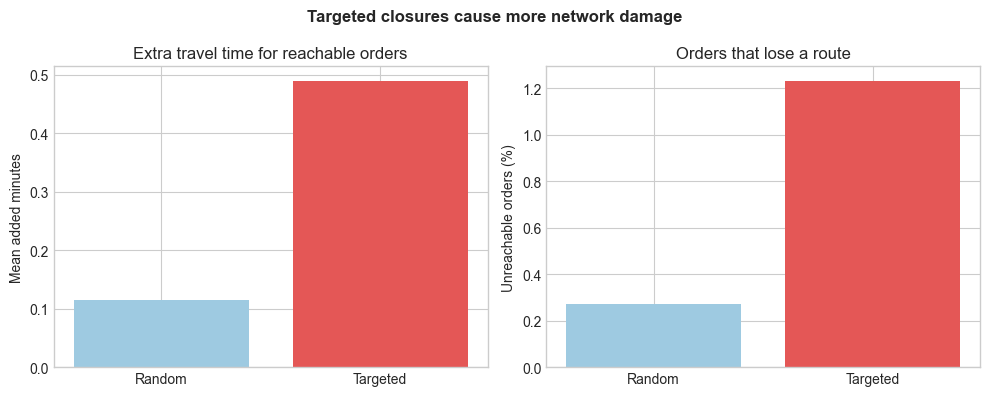

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ["#9ECAE1", "#E45756"]

axes[0].bar(
    network_comparison["scenario"],
    network_comparison["mean_added_min"],
    color=colors,
)
axes[0].set_title("Extra travel time for reachable orders")
axes[0].set_ylabel("Mean added minutes")

axes[1].bar(
    network_comparison["scenario"],
    100 - network_comparison["reachable_pct"],
    color=colors,
)
axes[1].set_title("Orders that lose a route")
axes[1].set_ylabel("Unreachable orders (%)")

fig.suptitle("Targeted closures cause more network damage", fontweight="bold")
plt.tight_layout()
plt.show()


Targeted closures are much worse than random closures:

- Mean added travel time: **0.49 minutes targeted** versus **0.13 minutes random**.
- Targeted closures create about **3.87 times more delay** among reachable orders.
- Targeted closures make **187 orders unreachable**. Random closures make about **45.6 orders unreachable on average**.
- Therefore, targeted closures cause about **4.10 times more route failures**.


## Does the effect depend on assignment strategy?


In [12]:
random_summary = (
    random_strategy_trials.groupby(["strategy", "fleet"], as_index=False)
    .agg(
        reachable_pct=("reachable_pct", "mean"),
        baseline_mean_min=("baseline_mean_min", "mean"),
        estimated_mean_min=("estimated_mean_min", "mean"),
        mean_added_min=("mean_added_min", "mean"),
        pct_increase=("pct_increase", "mean"),
    )
)
random_summary["scenario"] = "Random"

strategy_summary = pd.concat(
    [random_summary, targeted_summary],
    ignore_index=True,
).sort_values(["fleet", "strategy", "scenario"])

display_columns = [
    "fleet",
    "strategy",
    "scenario",
    "reachable_pct",
    "mean_added_min",
    "pct_increase",
]
strategy_summary[display_columns].round(3)


,fleet,strategy,scenario,reachable_pct,mean_added_min,pct_increase
0,200,nac,Random,99.727,0.115,0.083
4,200,nac,Targeted,98.769,0.489,0.355
2,200,swb,Random,99.727,0.115,0.089
6,200,swb,Targeted,98.769,0.489,0.380
1,500,nac,Random,99.727,0.115,0.532
5,500,nac,Targeted,98.769,0.489,2.264
3,500,swb,Random,99.727,0.115,0.517
7,500,swb,Targeted,98.769,0.489,2.201


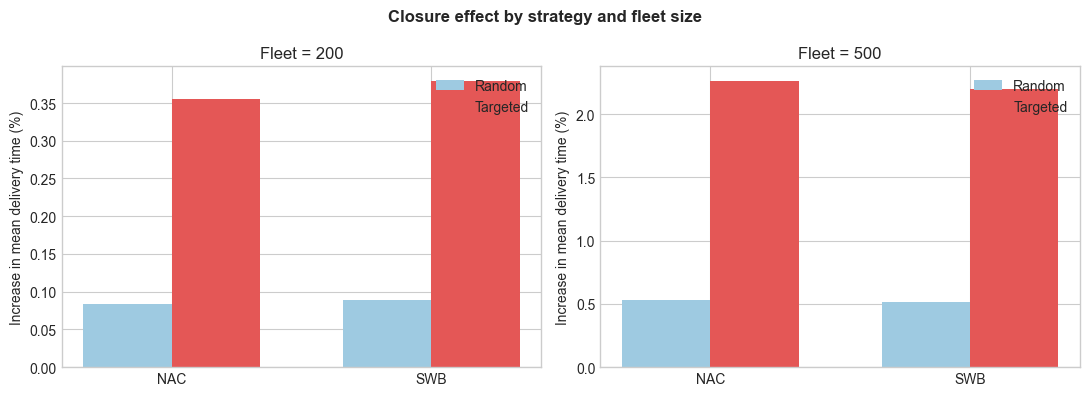

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, fleet_size in zip(axes, [200, 500]):
    plot_data = strategy_summary[strategy_summary["fleet"] == fleet_size]
    pivot = (
        plot_data.pivot(index="strategy", columns="scenario", values="pct_increase")
        .reindex(["nac", "swb"])
    )

    x = np.arange(len(pivot.index))
    width = 0.34
    ax.bar(x - width / 2, pivot["Random"], width, label="Random", color="#9ECAE1")
    ax.bar(x + width / 2, pivot["Targeted"], width, label="Targeted", color="#E45756")
    ax.set_xticks(x, [strategy.upper() for strategy in pivot.index])
    ax.set_title(f"Fleet = {fleet_size}")
    ax.set_ylabel("Increase in mean delivery time (%)")
    ax.legend(frameon=False)

fig.suptitle("Closure effect by strategy and fleet size", fontweight="bold")
plt.tight_layout()
plt.show()


The **absolute closure penalty does not meaningfully depend on NAC versus SWB**. For the same order, both strategies use the same restaurant and customer nodes, so each receives the same pickup-to-drop-off detour.

The percentage increase is larger with 500 couriers only because its original delivery times are much lower. Within the same fleet size, NAC and SWB have nearly identical percentage increases.


## Conclusion

**Targeted road closures cause substantially more damage than equally sized random closures.** Closing the 1% most-used delivery road segments adds **0.49 minutes** to reachable trips, compared with **0.13 minutes** under random closures. Targeted closures also make **187 orders unreachable**, compared with about **45.6 orders** under random closures.

**The added pickup-to-drop-off road damage is nearly the same for NAC and SWB.** Assignment strategy still changes the original delivery performance—SWB remains better with 200 couriers and NAC remains slightly better with 500—but neither strategy protects the final delivery route from a closure.

### Limitation

The data gives each order's pickup and drop-off nodes, but it does not give the courier's road-network position before pickup. Therefore, this experiment measures closure damage on the **pickup-to-drop-off route**. It cannot rerun courier assignment or measure closure effects on the courier's trip to the restaurant.
